# Iceland Tourism - Visualizations
Charts and insights based on cleaned data.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Wczytaj oczyszczone dane
df = pd.read_csv('../data/processed/overnight_stays_arrivals_clean.csv')
df_occ = pd.read_csv('../data/processed/occupancy_rate_clean.csv')
df_kef = pd.read_csv('../data/processed/keflavik_passengers_clean.csv')
df_gh = pd.read_csv('../data/processed/hotels_guesthouses_clean.csv')

month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

print("✅ Dane załadowane!")
print(f"overnight: {df.shape}, occupancy: {df_occ.shape}, keflavik: {df_kef.shape}, hotels: {df_gh.shape}")

✅ Dane załadowane!
overnight: (2034, 5), occupancy: (4242, 5), keflavik: (6966, 6), hotels: (40099, 6)


In [1]:
import os
print(os.getcwd())
print(os.listdir('../data/processed/'))

c:\Users\12lis\iceland-tourism-analysis\notebooks
['hotels_guesthouses_clean.csv', 'keflavik_passengers_clean.csv', 'occupancy_rate_clean.csv', 'overnight_stays_arrivals_clean.csv']


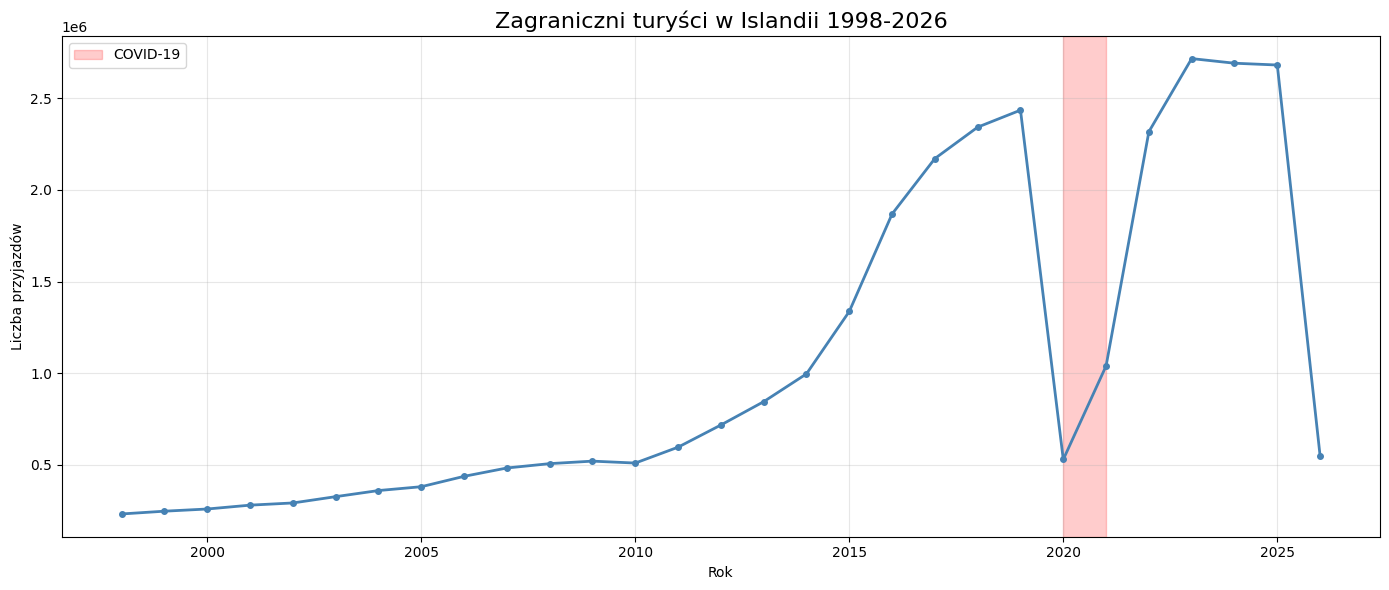

In [3]:
# Wykres 1 - Trend turystów zagranicznych
df_plot = df[
    (df['Citizenship'] == 'Foreigners') & 
    (df['Unit'] == 'Arrivals') &
    (df['Month'] != 'Total')
].groupby('Year')['Value'].sum().reset_index()

plt.figure(figsize=(14, 6))
plt.plot(df_plot['Year'], df_plot['Value'], color='steelblue', linewidth=2, marker='o', markersize=4)
plt.axvspan(2020, 2021, color='red', alpha=0.2, label='COVID-19')
plt.title('Zagraniczni turyści w Islandii 1998-2026', fontsize=16)
plt.xlabel('Rok')
plt.ylabel('Liczba przyjazdów')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/01_arrivals_trend.png', dpi=150)
plt.show()

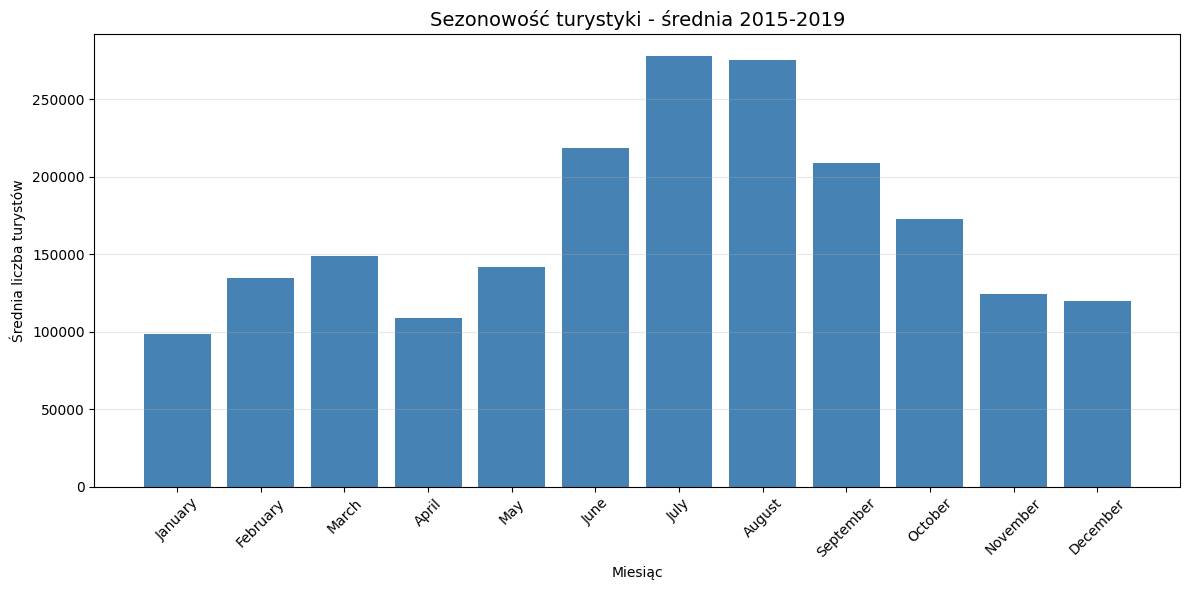

In [4]:
# Wykres 2 - Sezonowość
df_season = df[
    (df['Citizenship'] == 'Foreigners') & 
    (df['Unit'] == 'Arrivals') &
    (df['Year'].between(2015, 2019))
].groupby('Month')['Value'].mean().reindex(month_order).reset_index()

plt.figure(figsize=(12, 6))
plt.bar(df_season['Month'], df_season['Value'], color='steelblue')
plt.title('Sezonowość turystyki - średnia 2015-2019', fontsize=14)
plt.xlabel('Miesiąc')
plt.ylabel('Średnia liczba turystów')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/02_seasonality.png', dpi=150)
plt.show()

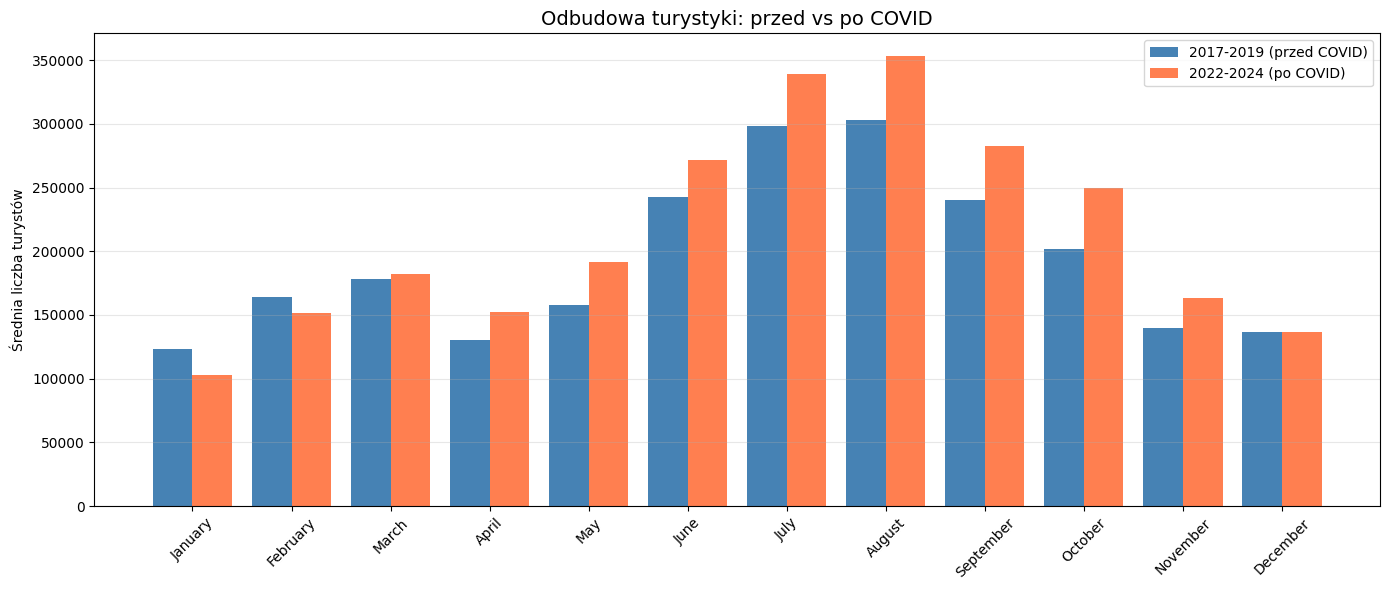

In [5]:
# Wykres 3 - COVID recovery
df_pre = df[
    (df['Citizenship'] == 'Foreigners') & 
    (df['Unit'] == 'Arrivals') &
    (df['Year'].between(2017, 2019))
].groupby('Month')['Value'].mean().reindex(month_order)

df_post = df[
    (df['Citizenship'] == 'Foreigners') & 
    (df['Unit'] == 'Arrivals') &
    (df['Year'].between(2022, 2024))
].groupby('Month')['Value'].mean().reindex(month_order)

x = range(len(month_order))
width = 0.4

plt.figure(figsize=(14, 6))
plt.bar([i - width/2 for i in x], df_pre, width, label='2017-2019 (przed COVID)', color='steelblue')
plt.bar([i + width/2 for i in x], df_post, width, label='2022-2024 (po COVID)', color='coral')
plt.title('Odbudowa turystyki: przed vs po COVID', fontsize=14)
plt.xticks(list(x), month_order, rotation=45)
plt.ylabel('Średnia liczba turystów')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/03_covid_recovery.png', dpi=150)
plt.show()

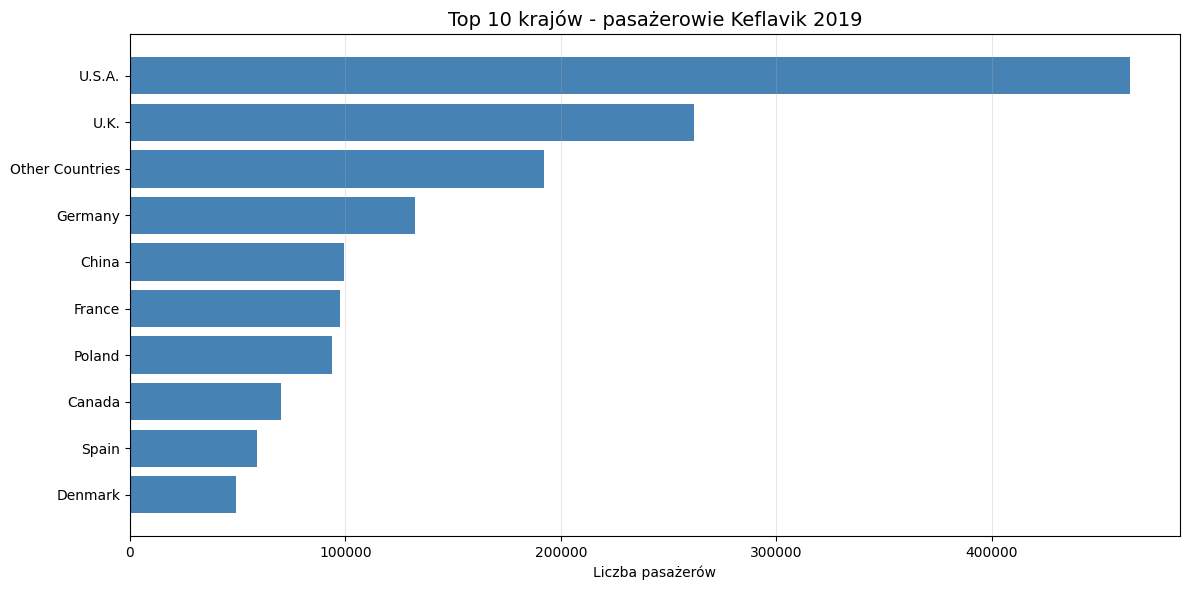

In [6]:
# Wykres 4 - Top 10 krajów Keflavik 2019
df_top = df_kef[
    (df_kef['Year'] == 2019) &
    (~df_kef['Country'].isin(['Total Passengers', 'Foreigners', 'Iceland']))
].groupby('Country')['Passengers'].sum().nlargest(10).reset_index()

plt.figure(figsize=(12, 6))
plt.barh(df_top['Country'][::-1], df_top['Passengers'][::-1], color='steelblue')
plt.title('Top 10 krajów - pasażerowie Keflavik 2019', fontsize=14)
plt.xlabel('Liczba pasażerów')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/04_top_countries.png', dpi=150)
plt.show()


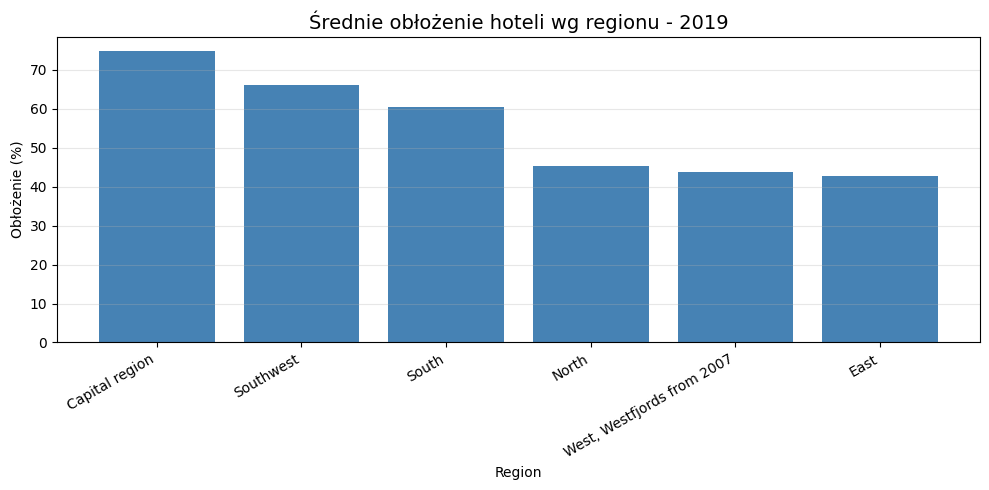

In [7]:
# Wykres 5 - Obłożenie wg regionu
df_reg = df_occ[
    (df_occ['Year'] == 2019) &
    (df_occ['Unit'] == 'Occupancy rate of rooms') &
    (df_occ['Type'] != 'Total')
].groupby('Type')['Value'].mean().reset_index().sort_values('Value', ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(df_reg['Type'], df_reg['Value'], color='steelblue')
plt.title('Średnie obłożenie hoteli wg regionu - 2019', fontsize=14)
plt.xlabel('Region')
plt.ylabel('Obłożenie (%)')
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/05_occupancy_by_region.png', dpi=150)
plt.show()